In [1]:
%pip install qiskit==1.2.4
%pip install qiskit-aer==0.15.1
%pip install pylatexenc==2.10

from qiskit import QuantumCircuit
from qiskit.converters import circuit_to_gate
from qiskit.visualization import array_to_latex
from qiskit.quantum_info import Operator
from qiskit.quantum_info import Statevector
from qiskit import transpile
from qiskit.providers.basic_provider import BasicSimulator
from qiskit.visualization import plot_histogram
from qiskit.circuit import ControlledGate
import math

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.1.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


  Using cached qiskit-aer-0.15.1.tar.gz (6.6 MB)
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'
Failed to build qiskit-aer
Note: you may need to restart the kernel to use updated packages.


  error: subprocess-exited-with-error
  
  × Building wheel for qiskit-aer (pyproject.toml) did not run successfully.
  │ exit code: 1
  ╰─> [113 lines of output]
      C:\Users\Marc\AppData\Local\Temp\pip-build-env-6_g1lmb0\overlay\Lib\site-packages\setuptools\dist.py:765: SetuptoolsDeprecationWarning: License classifiers are deprecated.
      !!
      
              ********************************************************************************
              Please consider removing the following classifiers in favor of a SPDX license expression:
      
              License :: OSI Approved :: Apache Software License
      
              See https://packaging.python.org/en/latest/guides/writing-pyproject-toml/#license for details.
              ********************************************************************************
      
      !!
        self._finalize_license_expression()
      
      
      --------------------------------------------------------------------------------


Note: you may need to restart the kernel to use updated packages.


In [2]:
# The aim of the assignment is to simulate the BB84 key distribution protocol.

# This notebook is for a simulation of the protocol with an attacker, to demonstrate that the attacker can be detected.

## Quantum Random Number Generator

In [3]:
backend = BasicSimulator()

def quantum_random_bits(n):
    """Generates n random bits using quantum measurement of the |+> state."""
    bits = []
    for _ in range(n):
        qc = QuantumCircuit(1, 1)
        qc.h(0)
        qc.measure(0, 0)
        t_qc = transpile(qc, backend)
        result = backend.run(t_qc, shots=1).result()
        bits.append(int(list(result.get_counts().keys())[0]))
    return bits

## Alice's Part

Alice's first 10 generated bits:  [0, 1, 0, 0, 1, 0, 0, 1, 0, 1]
Alice's first 10 generated bases: [0, 0, 0, 1, 1, 1, 0, 1, 0, 0]
Example Alice's Circuit for Qubit 0 (Bit: 0, Basis: 0):


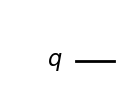

In [4]:
NUM_QUBITS = 100
alice_bits = quantum_random_bits(NUM_QUBITS)
alice_bases = quantum_random_bits(NUM_QUBITS)

print(f"Alice's first 10 generated bits:  {alice_bits[:10]}")
print(f"Alice's first 10 generated bases: {alice_bases[:10]}")

alice_qubits = []
for i in range(NUM_QUBITS):
    qc = QuantumCircuit(1)
    if alice_bits[i] == 1: qc.x(0)
    if alice_bases[i] == 1: qc.h(0)
    alice_qubits.append(qc)

print(f"Example Alice's Circuit for Qubit 0 (Bit: {alice_bits[0]}, Basis: {alice_bases[0]}):")
display(alice_qubits[0].draw('mpl'))

## Eve's Attack (Intercept-Resend)
Eve measures each qubit in a random basis and re-sends a new qubit based on her measurement.
This lets Eve try to learn the key, but it disturbs the qubits.

Eve's first 10 generated bases:   [1, 1, 1, 0, 0, 1, 1, 0, 1, 0]
Example Eve's Circuit for Qubit 0 (Basis: 1):


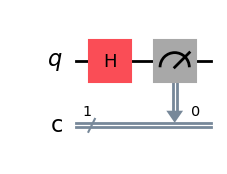

In [5]:
eve_bases = quantum_random_bits(NUM_QUBITS)
print(f"Eve's first 10 generated bases:   {eve_bases[:10]}")

intercepted_qubits = []

eve_example_qc = None

for i in range(NUM_QUBITS):
    qc = alice_qubits[i].copy()
    if eve_bases[i] == 1: qc.h(0)
    qc.add_register(__import__('qiskit').ClassicalRegister(1, 'c'))
    qc.measure(0, 0)
    if i == 0:
        eve_example_qc = qc
    t_qc = transpile(qc, backend)
    measured_bit = int(list(backend.run(t_qc, shots=1).result().get_counts().keys())[0])
    
    new_qc = QuantumCircuit(1)
    if measured_bit == 1: new_qc.x(0)
    if eve_bases[i] == 1: new_qc.h(0)
    intercepted_qubits.append(new_qc)

print(f"Example Eve's Circuit for Qubit 0 (Basis: {eve_bases[0]}):")
display(eve_example_qc.draw('mpl'))

## Bob's Part
Bob measures each received qubit in a random basis.

Bob's first 10 generated bases:   [1, 0, 0, 0, 0, 1, 0, 0, 0, 1]
Example Bob's Circuit for Qubit 0 (Basis: 1):


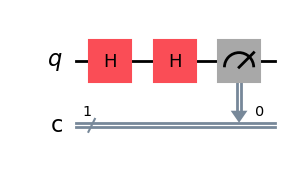

In [6]:
bob_bases = quantum_random_bits(NUM_QUBITS)
print(f"Bob's first 10 generated bases:   {bob_bases[:10]}")

bob_bits = []
bob_example_qc = None

for i in range(NUM_QUBITS):
    qc = intercepted_qubits[i].copy()
    if bob_bases[i] == 1: qc.h(0)
    qc.add_register(__import__('qiskit').ClassicalRegister(1, 'c'))
    qc.measure(0, 0)
    if i == 0:
        bob_example_qc = qc
    t_qc = transpile(qc, backend)
    bob_bits.append(int(list(backend.run(t_qc, shots=1).result().get_counts().keys())[0]))

print(f"Example Bob's Circuit for Qubit 0 (Basis: {bob_bases[0]}):")
display(bob_example_qc.draw('mpl'))

## Detection
Flag an attack if the observed error rate exceeds a chosen threshold.

In [7]:
matching = [i for i in range(NUM_QUBITS) if alice_bases[i] == bob_bases[i]]
alice_key = [alice_bits[i] for i in matching]
bob_key = [bob_bits[i] for i in matching]

check_len = len(alice_key) // 2
errors = sum(1 for i in range(check_len) if alice_key[i] != bob_key[i])
error_rate = errors / check_len if check_len > 0 else 0

threshold = 0.12
print(f"Error rate: {error_rate:.2%}")
print(f"Detection threshold: {threshold:.2%}")
if error_rate > threshold:
    print("ATTACK DETECTED!")

Error rate: 12.50%
Detection threshold: 12.00%
ATTACK DETECTED!
